In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [5]:
df = pd.read_csv('umkm_dataset.csv')

df.head()

,ID,Monthly_Revenue,Net_Profit_Margin (%),Burn_Rate_Ratio,Transaction_Count,Avg_Historical_Rating,Review_Text,Review_Volatility,Business_Tenure_Months,Repeat_Order_Rate (%),Digital_Adoption_Score,Peak_Hour_Latency,Location_Competitiveness,Sentiment_Score,Class,Date,Unnamed: 16,Unnamed: 17
0,1,6680716,22.72,0.811,161,4.75,"Transaksi digital lancar, proses checkout tida...",0.313,105,19.40,4.24,Low,9,-0.25,Growth,11/29/2021,NaN,NaN
1,2,5819101,4.46,0.968,104,4.21,"Harga dan kualitas seimbang, pengalaman biasa ...",0.632,95,14.87,1.27,Med,10,0.00,Growth,3/26/2022,NaN,NaN
2,3,5236404,-10.12,1.047,102,3.51,"Pelayanan standar, masih bisa ditingkatkan.",0.470,17,21.00,3.37,Med,8,0.00,Struggling,1/11/2026,NaN,NaN
3,4,8043552,0.04,0.969,99,4.33,"Transaksi digital lancar, proses checkout tida...",0.206,109,30.62,5.41,Low,13,-0.25,Growth,4/9/2024,NaN,NaN
4,5,6071256,4.22,0.954,115,4.34,Selalu repeat order karena kualitasnya terjaga...,0.232,74,20.87,2.67,Low,7,0.25,Growth,1/11/2025,NaN,NaN


In [6]:
cols = df.columns.tolist()
cols.insert(1, cols.pop(cols.index('Date')))
df = df[cols]

In [7]:
print("Shape data:", df.shape)

Shape data: (150000, 18)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150000 non-null  int64  
 1   Date                      150000 non-null  object 
 2   Monthly_Revenue           150000 non-null  int64  
 3   Net_Profit_Margin (%)     150000 non-null  float64
 4   Burn_Rate_Ratio           150000 non-null  float64
 5   Transaction_Count         150000 non-null  int64  
 6   Avg_Historical_Rating     150000 non-null  float64
 7   Review_Text               150000 non-null  object 
 8   Review_Volatility         150000 non-null  float64
 9   Business_Tenure_Months    150000 non-null  int64  
 10  Repeat_Order_Rate (%)     150000 non-null  float64
 11  Digital_Adoption_Score    150000 non-null  float64
 12  Peak_Hour_Latency         150000 non-null  object 
 13  Location_Competitiveness  150000 non-null  i

In [9]:
df.isnull().sum()

ID                               0
Date                             0
Monthly_Revenue                  0
Net_Profit_Margin (%)            0
Burn_Rate_Ratio                  0
Transaction_Count                0
Avg_Historical_Rating            0
Review_Text                      0
Review_Volatility                0
Business_Tenure_Months           0
Repeat_Order_Rate (%)            0
Digital_Adoption_Score           0
Peak_Hour_Latency                0
Location_Competitiveness         0
Sentiment_Score                  0
Class                            0
Unnamed: 16                 150000
Unnamed: 17                 150000
dtype: int64

In [10]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [11]:
df.describe()

,ID,Monthly_Revenue,Net_Profit_Margin (%),Burn_Rate_Ratio,Transaction_Count,Avg_Historical_Rating,Review_Volatility,Business_Tenure_Months,Repeat_Order_Rate (%),Digital_Adoption_Score,Location_Competitiveness,Sentiment_Score,Unnamed: 16,Unnamed: 17
count,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,0.0,0.0
mean,75000.500000,8.451726e+06,1.842272,0.969885,117.766667,4.061107,0.407203,91.006840,19.980521,3.546894,8.998807,-0.018946,NaN,NaN
std,43301.414527,5.291163e+06,15.002406,0.144039,42.618493,0.521698,0.166806,51.104736,8.021928,1.670303,2.828602,0.320534,NaN,NaN
min,1.000000,1.500000e+06,-35.000000,0.437000,9.000000,1.500000,0.060000,3.000000,2.000000,1.000000,1.000000,-0.650000,NaN,NaN
25%,37500.750000,4.745884e+06,-8.430000,0.869000,86.000000,3.770000,0.278000,47.000000,14.450000,2.260000,7.000000,-0.250000,NaN,NaN
50%,75000.500000,7.245678e+06,2.160000,0.966000,117.000000,4.100000,0.405000,91.000000,19.950000,3.480000,9.000000,0.000000,NaN,NaN
75%,112500.250000,1.083026e+07,12.310000,1.067000,149.000000,4.410000,0.526000,135.000000,25.430000,4.690000,11.000000,0.000000,NaN,NaN
max,150000.000000,8.206754e+07,45.000000,1.550000,285.000000,5.000000,0.990000,179.000000,54.060000,10.000000,23.000000,0.800000,NaN,NaN


In [12]:
df.drop(columns=['Unnamed: 16', 'Unnamed: 17'], inplace=True, errors='ignore')

In [13]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.dropna(inplace=True)

In [16]:
df['Monthly_Revenue'] = df['Monthly_Revenue'].clip(lower=0)
df['Transaction_Count'] = df['Transaction_Count'].clip(lower=0)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   ID                        150000 non-null  int64         
 1   Date                      150000 non-null  datetime64[ns]
 2   Monthly_Revenue           150000 non-null  int64         
 3   Net_Profit_Margin (%)     150000 non-null  float64       
 4   Burn_Rate_Ratio           150000 non-null  float64       
 5   Transaction_Count         150000 non-null  int64         
 6   Avg_Historical_Rating     150000 non-null  float64       
 7   Review_Text               150000 non-null  object        
 8   Review_Volatility         150000 non-null  float64       
 9   Business_Tenure_Months    150000 non-null  int64         
 10  Repeat_Order_Rate (%)     150000 non-null  float64       
 11  Digital_Adoption_Score    150000 non-null  float64       
 12  Pe

In [18]:
df.to_csv("clean_umkm_dataset.csv", index=False)

print("Data berhasil disimpan sebagai clean_umkm_dataset.csv")

Data berhasil disimpan sebagai clean_umkm_dataset.csv


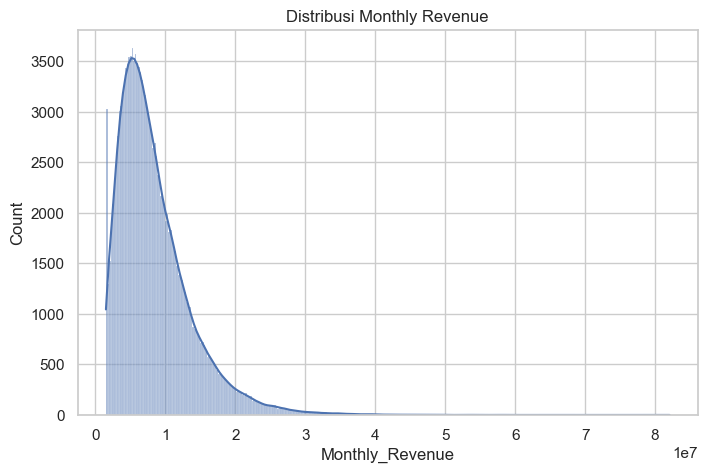

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly_Revenue'], kde=True)
plt.title('Distribusi Monthly Revenue')
plt.show()

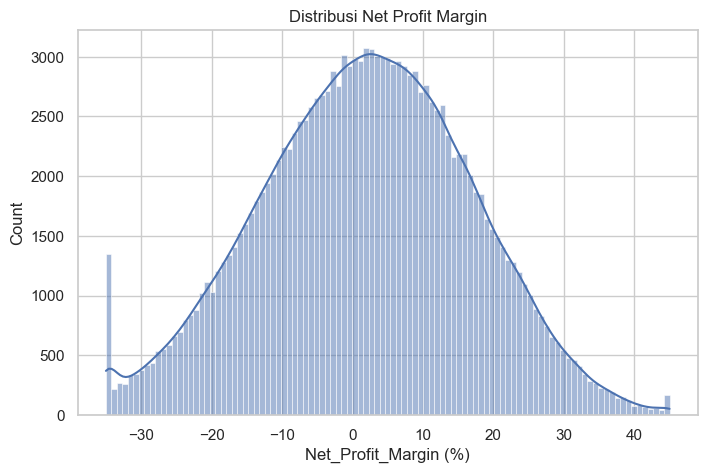

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Net_Profit_Margin (%)'], kde=True)
plt.title('Distribusi Net Profit Margin')
plt.show()

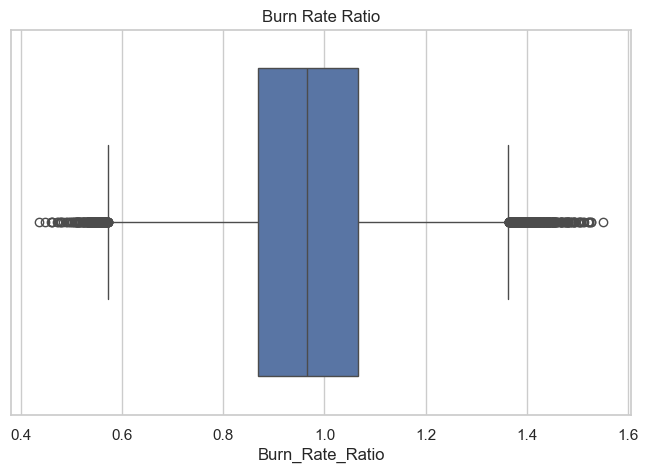

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Burn_Rate_Ratio'])
plt.title('Burn Rate Ratio')
plt.show()

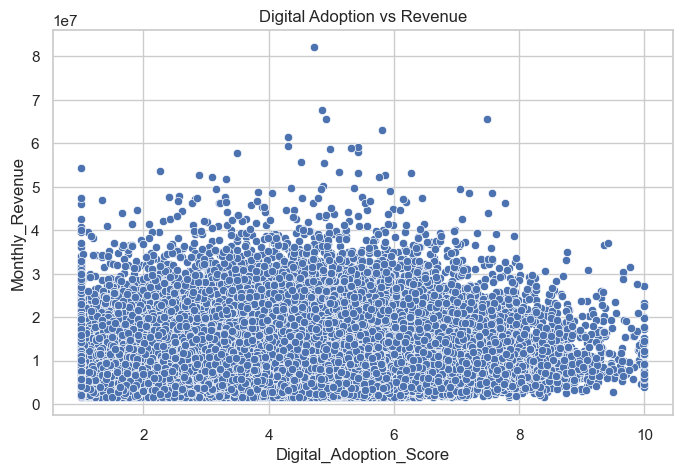

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Digital_Adoption_Score', y='Monthly_Revenue', data=df)
plt.title('Digital Adoption vs Revenue')
plt.show()

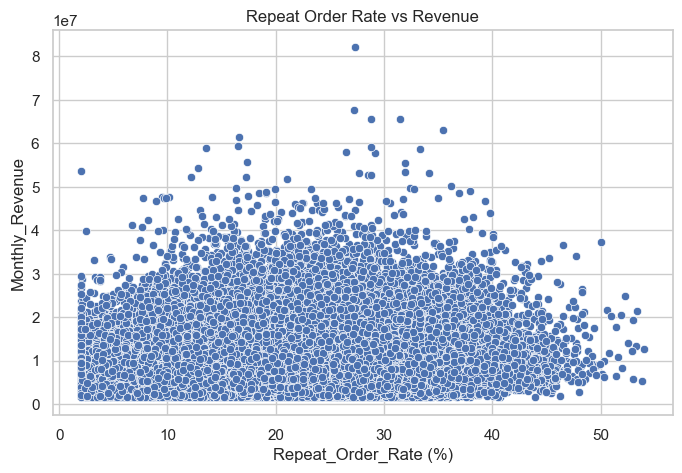

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Repeat_Order_Rate (%)', y='Monthly_Revenue', data=df)
plt.title('Repeat Order Rate vs Revenue')
plt.show()

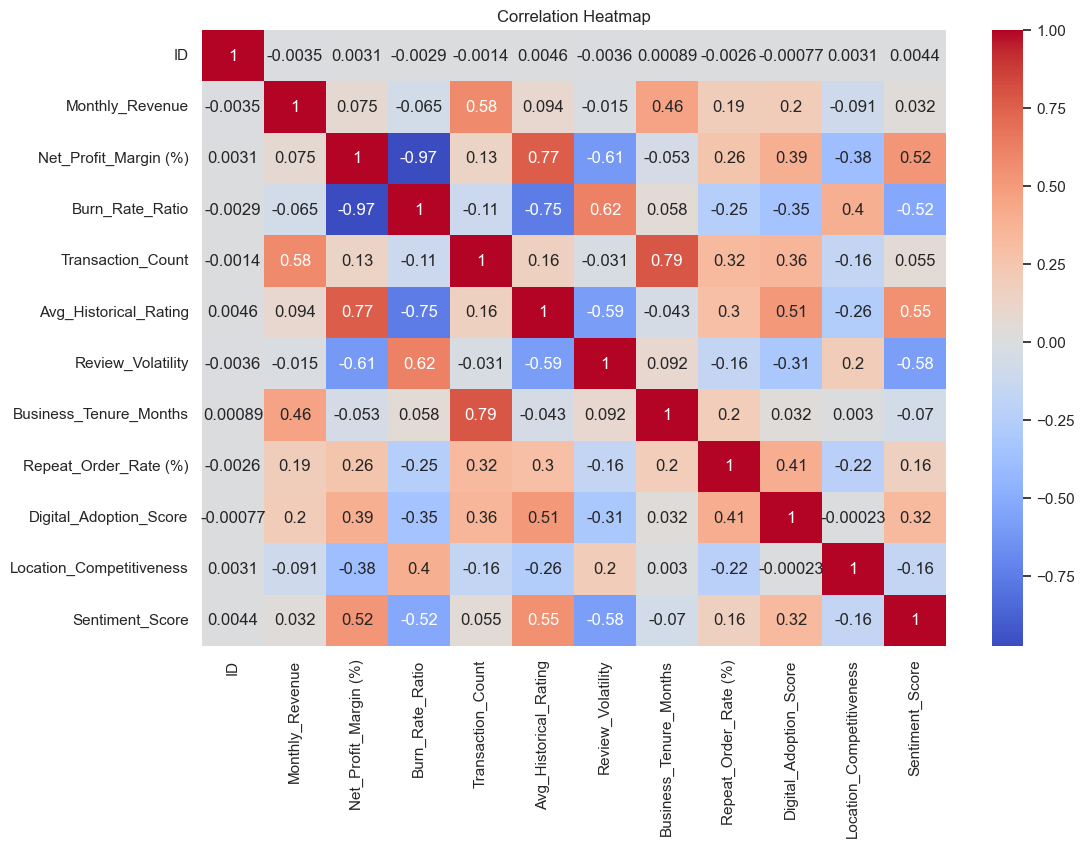

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

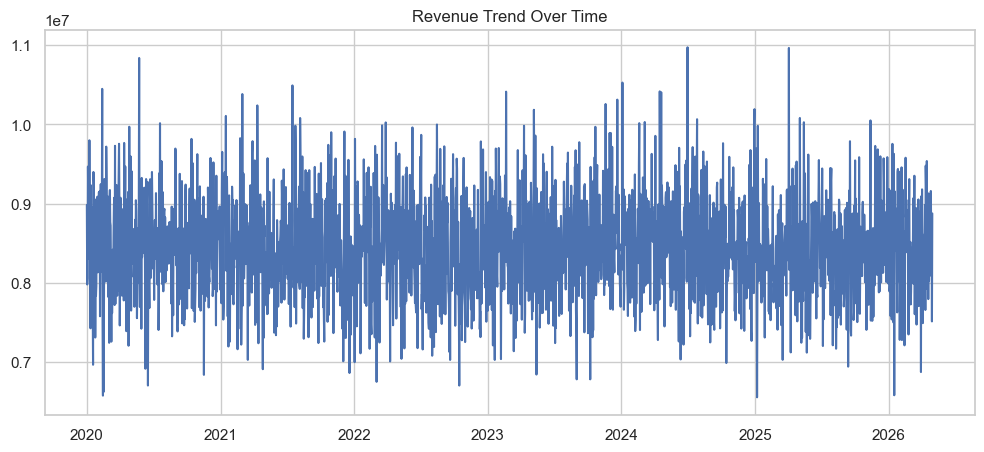

In [25]:
revenue_time = df.groupby('Date')['Monthly_Revenue'].mean()

plt.figure(figsize=(12,5))
plt.plot(revenue_time)
plt.title('Revenue Trend Over Time')
plt.show()

**MODEL 1**